In [ ]:
from google.colab import drive
import sys

# Mount Google Drive
drive.mount('/content/drive')

# Add the folder containing data_utils.py to the system path
sys.path.append('/content/drive/MyDrive/data')


Mounted at /content/drive


In [18]:
# --- Standard Libraries ---
import os
import cv2
import sys
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# --- Custom Utilities ---
from data_utils import (
    load_sample_dataframe_from_dir,
    load_dataset_from_df,
    load_dataset_from_dir,
    balance_data
)


# Load Best Model

In [19]:
# Load the best hyperparameter-tuned model from Drive
best_model_path = '/content/drive/MyDrive/data/cnn_model/best_cnn_model.keras'
best_model = load_model(best_model_path)
print(f"✅ Loaded best model from: {best_model_path}")


✅ Loaded best model from: /content/drive/MyDrive/data/cnn_model/best_cnn_model.keras


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Model Training and Evaluation
The following function trains the CNN model that is defined above. Once the model is trained, the metrics (accuracy, precision, recall and f1) are extracted from the model. The precision and recall metrics are important in addition to accuracy because of the large class imbalance in this dataset. These are good metrics to compare model performance against different input data configurations. These metrics are written to a named csv file that can be referenced later, and also used for plotting the results.

In [24]:
num_epochs = 30

def train_and_evaluate(model, train_ds, val_ds, test_ds, test_description="example_test"):
    results_path = f"{test_description}_results.csv"

    # Callbacks for training
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=1)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=num_epochs,
        callbacks=[lr_scheduler, early_stopping]
    )

    # Reset test_ds if applicable
    if hasattr(test_ds, 'reset'):
        test_ds.reset()

    # Predictions (fixed to go through test set exactly once)
    y_true, y_pred = [], []
    steps = test_ds.samples // test_ds.batch_size
    if test_ds.samples % test_ds.batch_size != 0:
        steps += 1

    for i in range(steps):
        images, labels = next(test_ds)
        predictions = model.predict(images, verbose=0)
        binary_preds = (predictions > 0.6).astype(int).flatten()
        y_true.extend(labels.astype(int))
        y_pred.extend(binary_preds)

    # Metrics
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    report = classification_report(y_true, y_pred, output_dict=True)
    class_0_precision = report['0']['precision']
    class_0_recall = report['0']['recall']
    class_1_precision = report['1']['precision']
    class_1_recall = report['1']['recall']

    results_df = pd.DataFrame({
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1],
        'Class_0_Precision': [class_0_precision],
        'Class_0_Recall': [class_0_recall],
        'Class_1_Precision': [class_1_precision],
        'Class_1_Recall': [class_1_recall]
    })

    results_df.to_csv(results_path, index=False)
    print("Metrics saved to", results_path)
    print(classification_report(y_true, y_pred))
    return history, y_true, y_pred, results_df


## Results
The following function creates 3 different plots to show the metrics for training and validation. The first plot is the training and validation accuracy comparison. The second plot is the loss function for training and testing and the final plot shows the recall metrics.

In [25]:
# Function to visualize results
def plot_results(history, y_true, y_pred, test_description):
    # accuracy metric
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Training & Validation Accuracy')
    plt.savefig(f"{test_description}_accuracy.png")

    # loss function
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Training & Validation Loss')
    plt.savefig(f"{test_description}_loss.png")

    # recall metric
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.legend()
    plt.title('Training & Validation Recall')
    plt.savefig(f"{test_description}_recall.png")

    plt.show()

# Run CNN on Vanilla Code Base
The remaining code blocks run the functions defined above. To change the data being processed, the different settings should be changed here. The dataset path as well as the training, validation and testing datasets can be loaded according to desired test.

In [26]:
# Use Kaggle data as base

# --- Paths ---
normal_data_path = '/content/drive/MyDrive/data/chest_xray/train/NORMAL'
pneumonia_data_path = '/content/drive/MyDrive/data/chest_xray/train/PNEUMONIA'
test_data_path = '/content/drive/MyDrive/data/chest_xray/test'

# --- Build and split DataFrames ---
train_df = pd.DataFrame(columns=['filename', 'class'])
train_df = load_sample_dataframe_from_dir(train_df, normal_data_path, 'NORMAL', sample_size=1341, seed=42)
train_df = load_sample_dataframe_from_dir(train_df, pneumonia_data_path, 'PNEUMONIA', sample_size=3875, seed=42)

# Stratified train/val split
search_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['class'], random_state=42)

# --- Create datasets ---
search_ds = load_dataset_from_df(search_df, "filename", "class", img_size=(224, 224), batch_size=32)
val_ds = load_dataset_from_df(val_df, "filename", "class", img_size=(224, 224), batch_size=32)
test_ds = load_dataset_from_dir(test_data_path, img_size=(224, 224), batch_size=32, gaussian_blur=False)


Found 4172 validated image filenames belonging to 2 classes.
Found 1044 validated image filenames belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 461ms/step - accuracy: 0.9690 - loss: 0.2160 - precision: 0.9904 - recall: 0.9680 - val_accuracy: 0.9770 - val_loss: 0.1639 - val_precision: 0.9870 - val_recall: 0.9820 - learning_rate: 1.0000e-04
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 443ms/step - accuracy: 0.9849 - loss: 0.1549 - precision: 0.9925 - recall: 0.9870 - val_accuracy: 0.9531 - val_loss: 0.2328 - val_precision: 0.9973 - val_recall: 0.9394 - learning_rate: 1.0000e-04
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.9837 - loss: 0.1433 - precision: 0.9933 - recall: 0.9847 - val_accuracy: 0.9837 - val_loss: 0.1354 - val_precision: 0.9935 - val_recall: 0.9845 - learning_rate: 1.0000e-04
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.9862 - loss: 0.1317 - precision: 0.9913 - recall: 0.9901 - val_accuracy: 0.9770 - val_loss: 0.1332 - val_precision: 0.9784 - val_recall: 0.9910 - learning_rate: 1.0000e-04
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 5

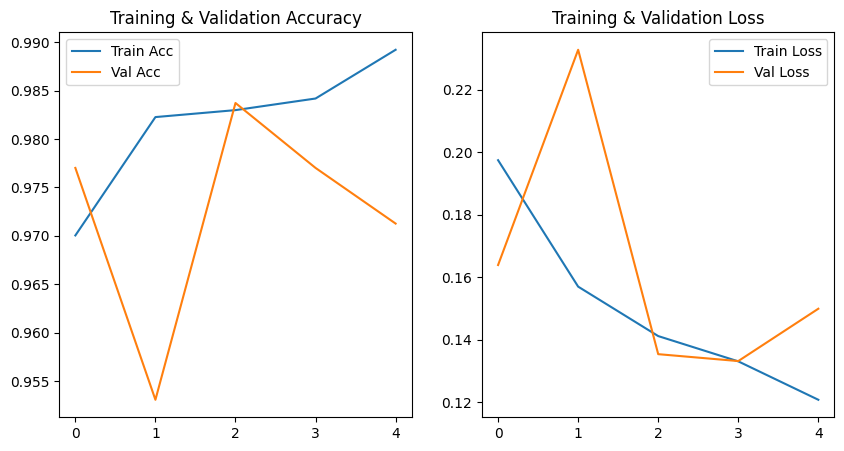

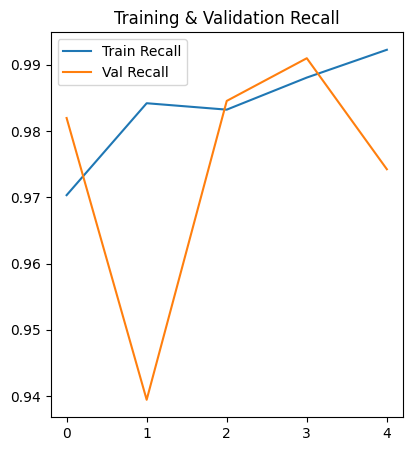

In [27]:
# Evaluate the best model from the tuner
test_description = "tuned_cnn_vanilla"

history, y_true, y_pred, results_df = train_and_evaluate(
    model=best_model,
    train_ds=search_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history, y_true, y_pred, test_description)


## Balanced Data
The next test uses only the kaggle dataset, but balances it so there is not a majority class like what exists in the actual dataset.

Found 2145 validated image filenames belonging to 2 classes.
Found 537 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 585ms/step - accuracy: 0.9618 - loss: 0.1795 - precision: 0.9319 - recall: 0.9944 - val_accuracy: 0.9497 - val_loss: 0.1935 - val_precision: 0.9959 - val_recall: 0.9030 - learning_rate: 1.0000e-04
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 531ms/step - accuracy: 0.9835 - loss: 0.1194 - precision: 0.9755 - recall: 0.9923 - val_accuracy: 0.9795 - val_loss: 0.1416 - val_precision: 0.9742 - val_recall: 0.9851 - learning_rate: 1.0000e-04
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 529ms/step - accuracy: 0.9889 - loss: 0.1141 - precision: 0.9865 - recall: 0.9910 - val_accuracy: 0.9088 - val_loss: 0.2575 - val_precision: 0.8454 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 537ms/step - accuracy: 0.9950 - loss: 0.0898 - precision: 0.9925 - recall: 0.9975 - val_accuracy: 0.9777 - val_loss: 0.1402 - val_precision: 0.9604 - val_recall: 0.9963 - learning_rate: 1.0000e-04
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 535ms/s

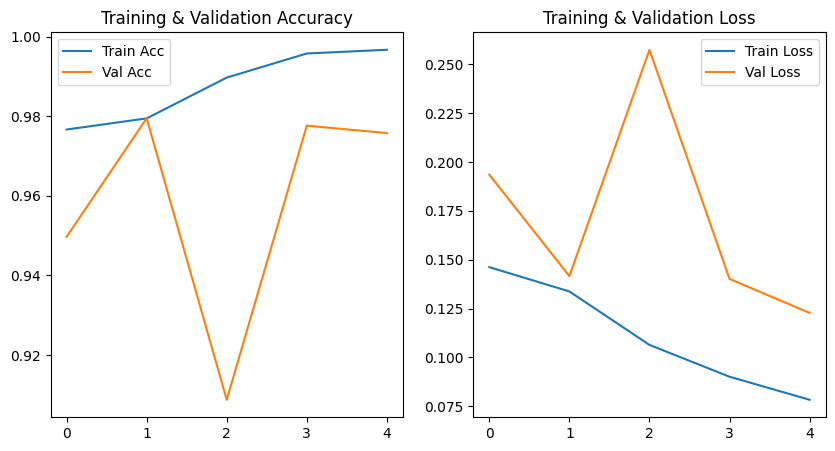

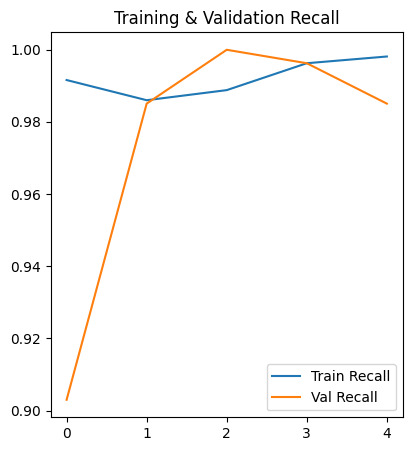

In [28]:
# Balance the training data
balanced_train_df = balance_data('/content/drive/MyDrive/data/chest_xray/train')

# Split into new search/val sets
search_df_bal, val_df_bal = train_test_split(
    balanced_train_df,
    test_size=0.2,
    stratify=balanced_train_df['class'],
    random_state=42
)

# Create balanced datasets
train_ds_bal = search_ds_bal = load_dataset_from_df(search_df_bal, "filename", "class", img_size=(224, 224), batch_size=32)
val_ds_bal = load_dataset_from_df(val_df_bal, "filename", "class", img_size=(224, 224), batch_size=32)

# Evaluate best model on balanced data
test_description = "tuned_cnn_balanced"

history_bal, y_true_bal, y_pred_bal, results_df_bal = train_and_evaluate(
    model=best_model,
    train_ds=train_ds_bal,
    val_ds=val_ds_bal,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history_bal, y_true_bal, y_pred_bal, test_description)



## Different Tests to Try
This section will be used to track the different tests preformed to ensure model training and data testing is going well and we are able to fully understand the impact synthetic data makes on the accuracy and precision and recall of the CNN model for classifying Pneumonia and Normal lungs.

- [ ] Full Kaggle Dataset only (Base CNN)
- [ ] Full Kaggle Dataset only (Transfer learning)
- [ ] Balanced Kaggle Dataset only (Base CNN)
- [ ] Balanced Kaggle Dataset only (Transfer learning)
- [ ] Only Pneumonia Synthetic -- Pawan (Base CNN)
- [ ] Only Pneumonia Synthetic -- Pawan (Transfer Learning)
- [ ] Only Normal Synthetic -- Pawan (Base CNN)
- [ ] Only Normal Synthetic -- Pawan (Transfer Learning)
- [ ] Balanced Synthetic Only -- Pawan (Base CNN)
- [ ] Balanced Synthetic Only -- Pawan (Transfer Learning)
- [ ] Only Pneumonia Synthetic -- Ned (Base CNN)
- [ ] Only Pneumonia Synthetic -- Ned (Transfer Learning)
[ ] Only Normal Synthetic -- Ned (Base CNN)
[ ] Only Normal Synthetic -- Ned (Transfer Learning)
[ ] Balanced Synthetic Only -- Ned (Base CNN)
[ ] Balanced Synthetic Only -- Ned (Transfer Learning)
[ ] Balanced Synthetic and Kaggle Dataset (Base CNN)
[ ] Balanced Synthetic and Kaggle Dataset (Transfer Learning)

## AC GAN
The following sections loads the ARC GAN images and trains the CNN model using these images. These images are also used for the validation. The test images are from the Kaggle Dataset.

In [29]:
# --- Paths ---
acgan_data_path = '/content/drive/MyDrive/data/ACGAN_128'
test_data_path = '/content/drive/MyDrive/data/chest_xray/test'

# --- Build full dataframe from ACGAN synthetic data ---
acgan_df = balance_data(acgan_data_path)  # Balanced already (1000 each, just standardizing flow)

# --- Split into train and val ---
train_df_acgan, val_df_acgan = train_test_split(
    acgan_df,
    test_size=0.2,
    stratify=acgan_df['class'],
    random_state=42
)

# --- Create datasets ---
train_ds_acgan = load_dataset_from_df(train_df_acgan, "filename", "class", img_size=(224, 224), batch_size=32)
val_ds_acgan = load_dataset_from_df(val_df_acgan, "filename", "class", img_size=(224, 224), batch_size=32)
test_ds = load_dataset_from_dir(test_data_path, img_size=(224, 224), batch_size=32, gaussian_blur=False)


Found 1600 validated image filenames belonging to 2 classes.
Found 400 validated image filenames belonging to 2 classes.
Found 624 images belonging to 2 classes.


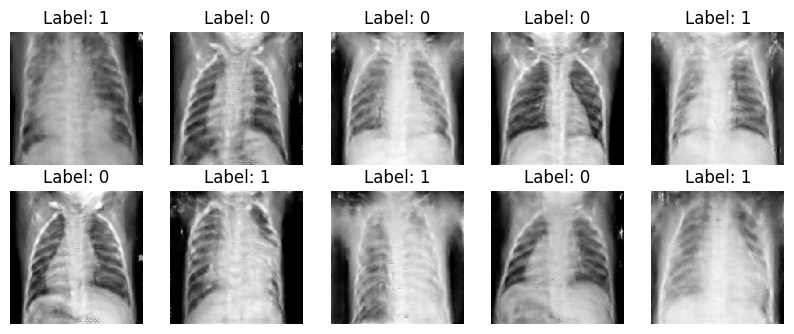

In [30]:
# Visualize first 10 synthetic images from ACGAN training set
images, labels = next(iter(train_ds_acgan))
plt.figure(figsize=(10, 10))
for i in range(10):
    ax = plt.subplot(5, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 389s 8s/step - accuracy: 0.8871 - loss: 0.3840 - precision: 0.8481 - recall: 0.9435 - val_accuracy: 0.9225 - val_loss: 0.2155 - val_precision: 0.8658 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 232ms/step - accuracy: 0.9906 - loss: 0.1192 - precision: 0.9891 - recall: 0.9924 - val_accuracy: 0.9825 - val_loss: 0.1108 - val_precision: 0.9754 - val_recall: 0.9900 - learning_rate: 1.0000e-04
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - accuracy: 0.9918 - loss: 0.0997 - precision: 0.9876 - recall: 0.9966 - val_accuracy: 0.9950 - val_loss: 0.0934 - val_precision: 0.9901 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 235ms/step - accuracy: 0.9982 - loss: 0.0809 - precision: 0.9965 - recall: 0.9999 - val_accuracy: 1.0000 - val_loss: 0.0728 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 237ms/ste

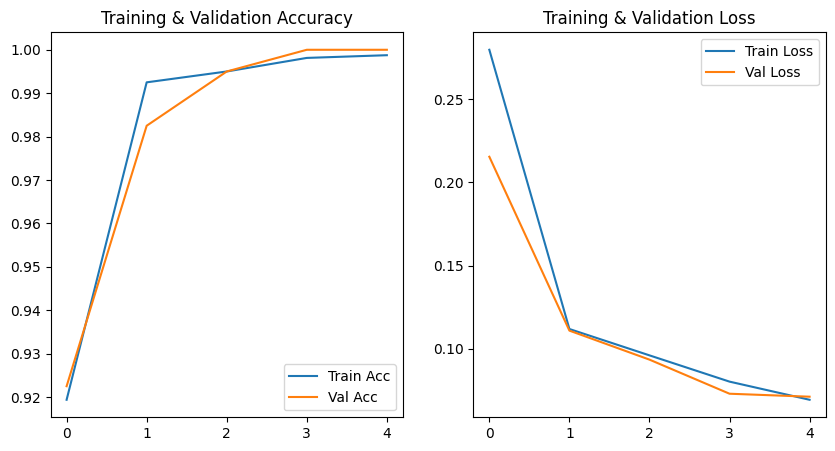

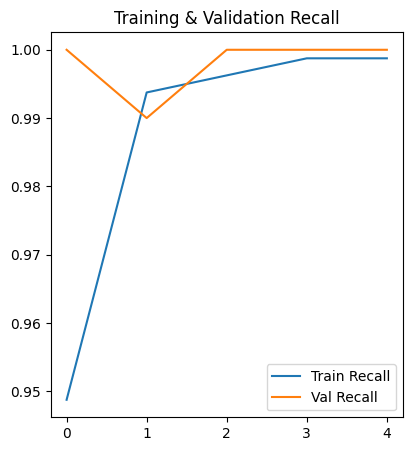

In [31]:
# Train and evaluate using synthetic (ACGAN) training data
test_description = "tuned_cnn_acgan"

history_acgan, y_true_acgan, y_pred_acgan, results_df_acgan = train_and_evaluate(
    model=best_model,
    train_ds=train_ds_acgan,
    val_ds=val_ds_acgan,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history_acgan, y_true_acgan, y_pred_acgan, test_description)


## Style GAN
The following section uses the synthetically generated images from the Style GAN. The train and validation sets are all synthetic images, while the test data comes from the original data in Kaggle. This is to help compare performance of the model on the same tests.

In [34]:
# --- Paths ---
stylegan_data_path = '/content/drive/MyDrive/data/StyleGAN_128'
test_data_path = '/content/drive/MyDrive/data/chest_xray/test'

# --- Build full dataframe from STYLEGAN synthetic data ---
stylegan_df = balance_data(stylegan_data_path)

# --- Split into train and val ---
train_df_stylegan, val_df_stylegan = train_test_split(
    stylegan_df,
    test_size=0.2,
    stratify=stylegan_df['class'],
    random_state=42
)

# --- Create datasets ---
train_ds_stylegan = load_dataset_from_df(train_df_stylegan, "filename", "class", img_size=(224, 224), batch_size=32)
val_ds_stylegan = load_dataset_from_df(val_df_stylegan, "filename", "class", img_size=(224, 224), batch_size=32)
test_ds = load_dataset_from_dir(test_data_path, img_size=(224, 224), batch_size=32, gaussian_blur=False)


Found 1600 validated image filenames belonging to 2 classes.
Found 400 validated image filenames belonging to 2 classes.
Found 624 images belonging to 2 classes.


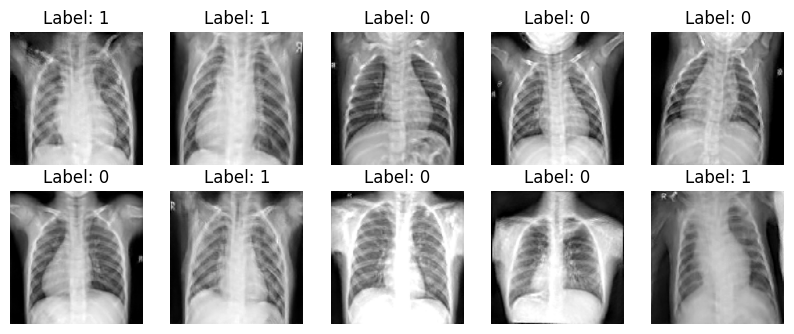

In [35]:
# Visualize first 10 synthetic images from STYLEGAN training set
images, labels = next(iter(train_ds_stylegan))
plt.figure(figsize=(10, 10))
for i in range(10):
    ax = plt.subplot(5, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 373s 7s/step - accuracy: 0.9462 - loss: 0.2128 - precision: 0.9370 - recall: 0.9528 - val_accuracy: 0.9450 - val_loss: 0.1847 - val_precision: 0.9944 - val_recall: 0.8950 - learning_rate: 1.0000e-04
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - accuracy: 0.9932 - loss: 0.0949 - precision: 0.9923 - recall: 0.9941 - val_accuracy: 0.9975 - val_loss: 0.0771 - val_precision: 0.9950 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 235ms/step - accuracy: 1.0000 - loss: 0.0719 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9950 - val_loss: 0.0774 - val_precision: 0.9901 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 232ms/step - accuracy: 1.0000 - loss: 0.0656 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9750 - val_loss: 0.1383 - val_precision: 0.9524 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/ste

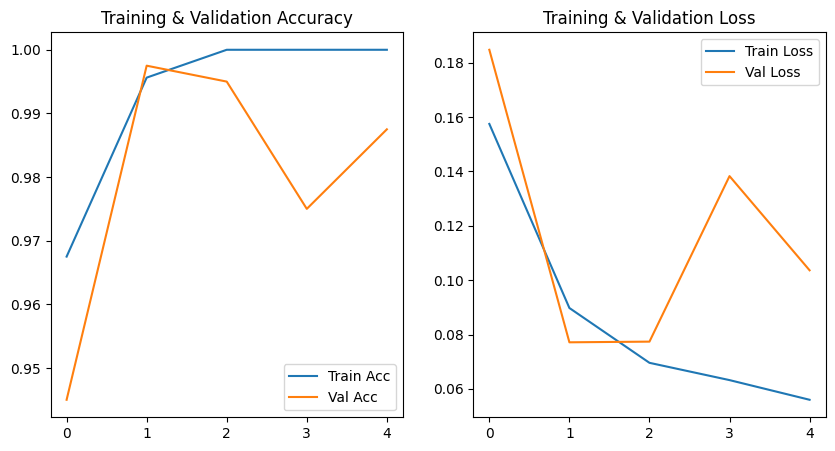

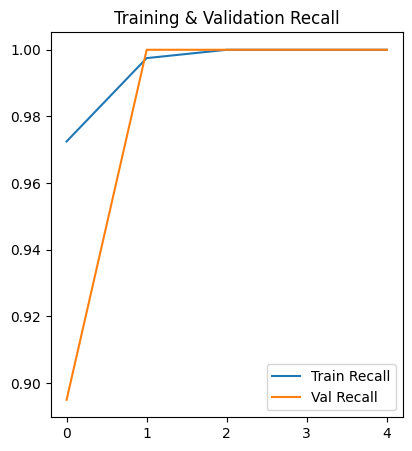

In [36]:
# Train and evaluate using STYLEGAN-generated synthetic data
test_description = "tuned_cnn_stylegan"

history_stylegan, y_true_stylegan, y_pred_stylegan, results_df_stylegan = train_and_evaluate(
    model=best_model,
    train_ds=train_ds_stylegan,
    val_ds=val_ds_stylegan,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history_stylegan, y_true_stylegan, y_pred_stylegan, test_description)
